# MULTIPLE LINEAR REGRESSION

## Task - Multiple linear regression analysis to predict the price of Toyota corolla based on the given attributes.

In [1]:
# importing libraries
import pandas as pd # to read the files and handling dataset
import numpy as np # for mathematical operations
import matplotlib.pyplot as plt # graphical visualization
import seaborn as sns # statistical visualization

In [2]:
df = pd.read_csv(r"C:\Users\rasika\Downloads\Multiple Linear Regression (1)\ToyotaCorolla - MLR.csv")
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [3]:
# summary 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [4]:
# statistical summary
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [5]:
# to check for missing values
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [6]:
# to check for duplicate rows
df.duplicated().sum()

np.int64(1)

In [7]:
# to remove the duplicate row
df.drop_duplicates(inplace = True)

In [8]:
# after removing duplicate again checking to ensure duplicate is removed
df.duplicated().sum()

np.int64(0)

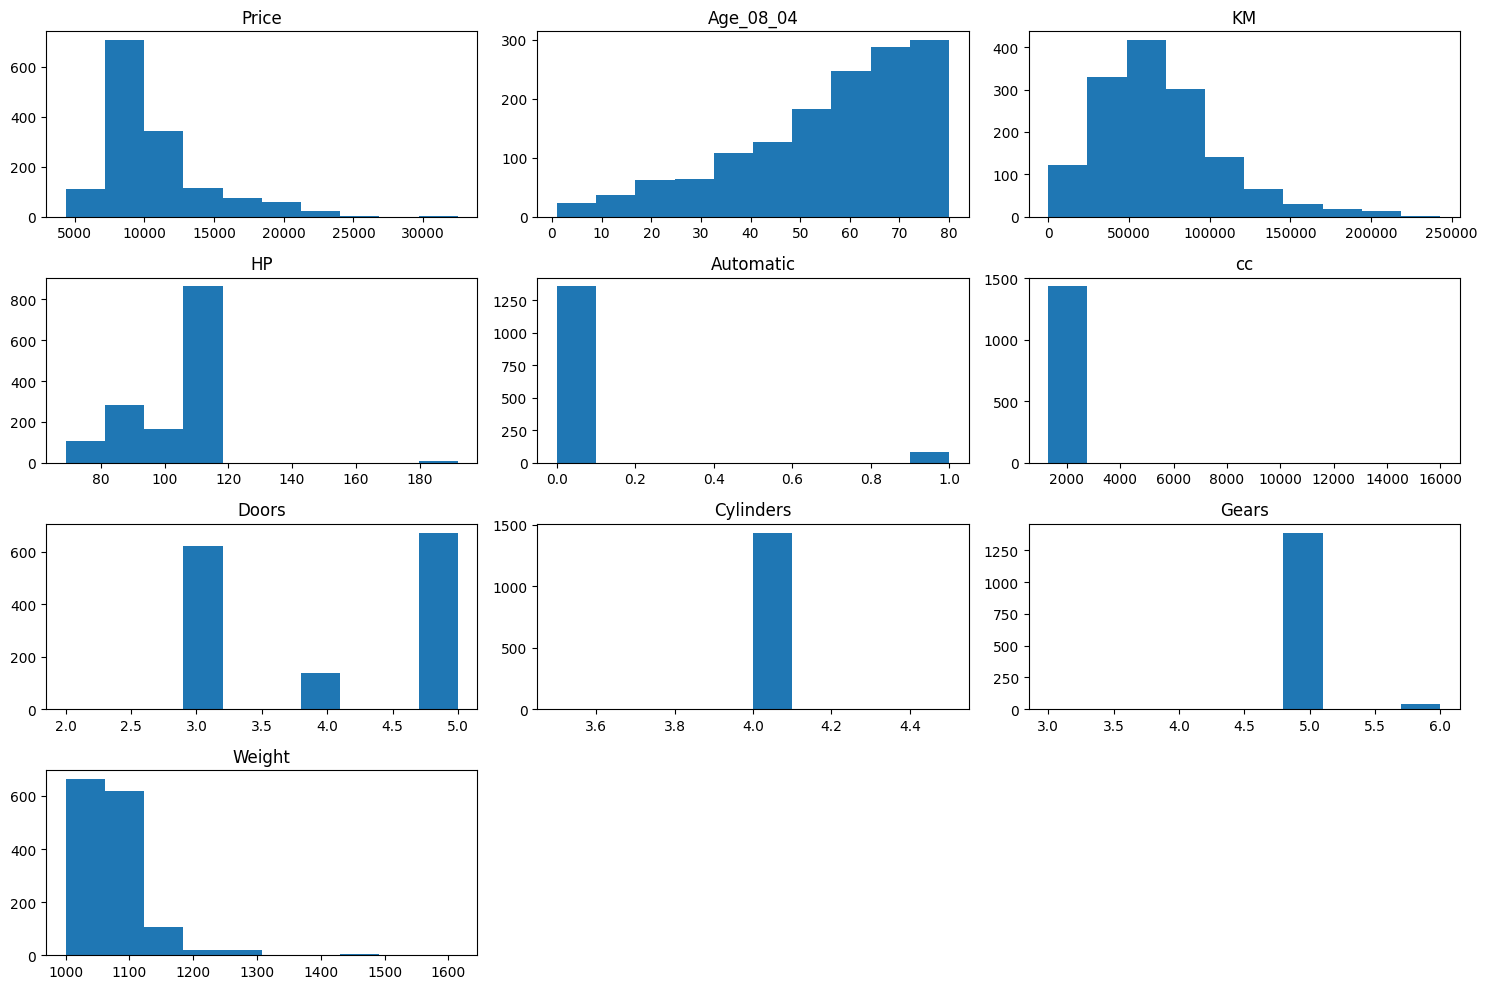

In [9]:
# Histogram to check for data distribution
df.hist(grid = False, figsize = (15, 10))
plt.tight_layout()
plt.show()

#### to check for outliers and remove outliers

<Axes: >

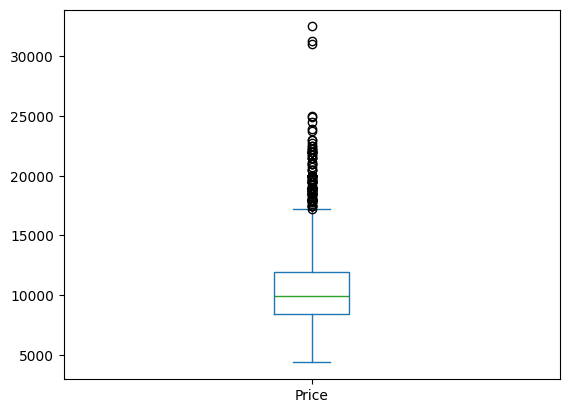

In [10]:
df['Price'].plot(kind = 'box')

In [11]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Price'] = df['Price'].clip(lower, upper)

<Axes: >

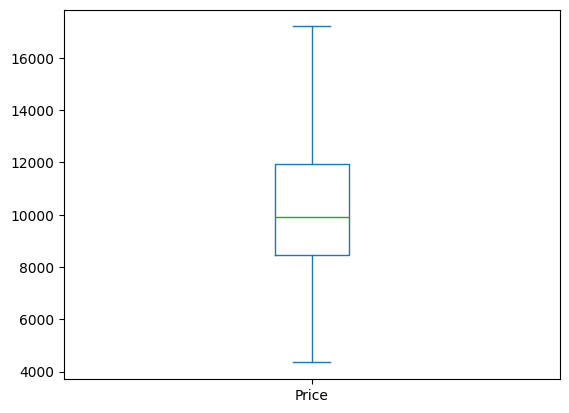

In [12]:
df['Price'].plot(kind = 'box')

<Axes: >

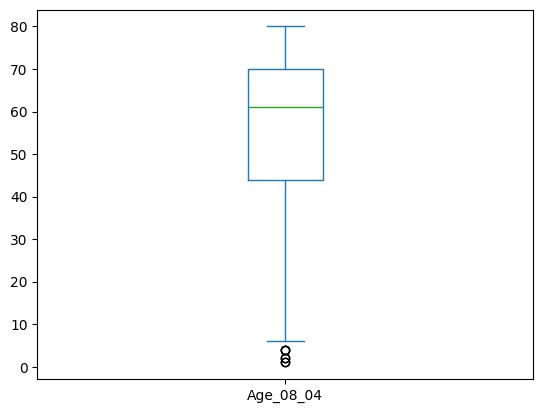

In [13]:
df['Age_08_04'].plot(kind = 'box')

In [14]:
Q1 = df['Age_08_04'].quantile(0.25)
Q3 = df['Age_08_04'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Age_08_04'] = df['Age_08_04'].clip(lower, upper)

<Axes: >

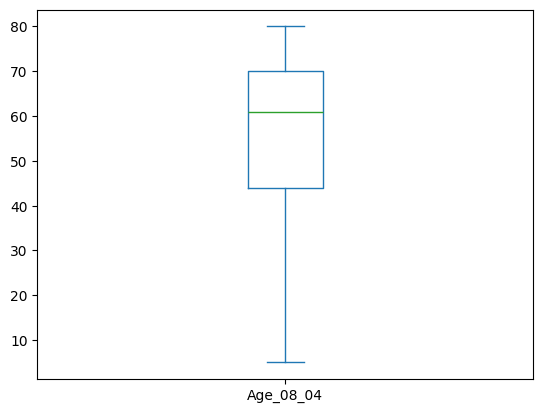

In [15]:
df['Age_08_04'].plot(kind = 'box')

<Axes: >

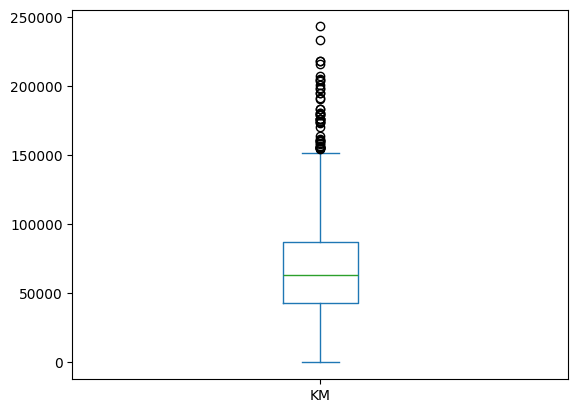

In [16]:
df['KM'].plot(kind = 'box')

In [17]:
Q1 = df['KM'].quantile(0.25)
Q3 = df['KM'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['KM'] = df['KM'].clip(lower, upper)

<Axes: >

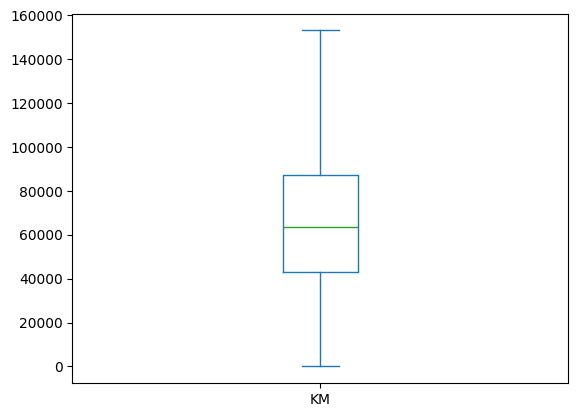

In [18]:
df['KM'].plot(kind = 'box')

<Axes: >

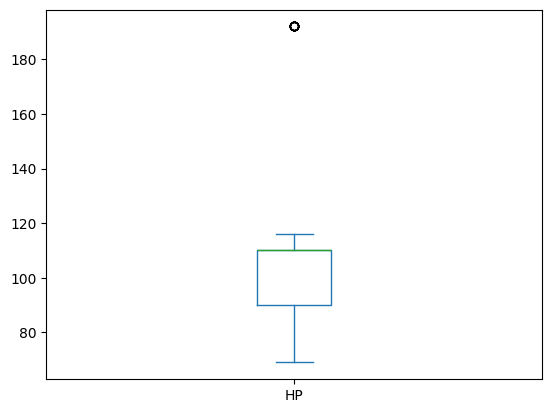

In [19]:
df['HP'].plot(kind = 'box')

In [20]:
Q1 = df['HP'].quantile(0.25)
Q3 = df['HP'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['HP'] = df['HP'].clip(lower, upper)

<Axes: >

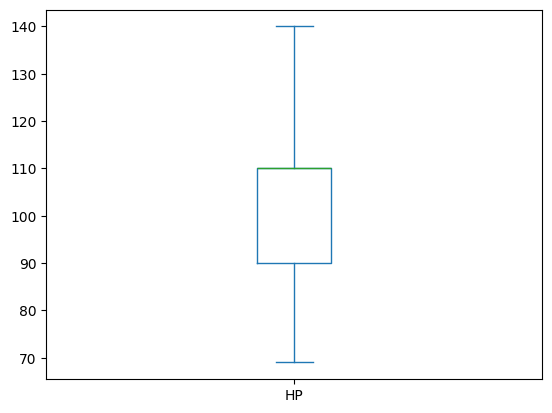

In [21]:
df['HP'].plot(kind = 'box')

<Axes: >

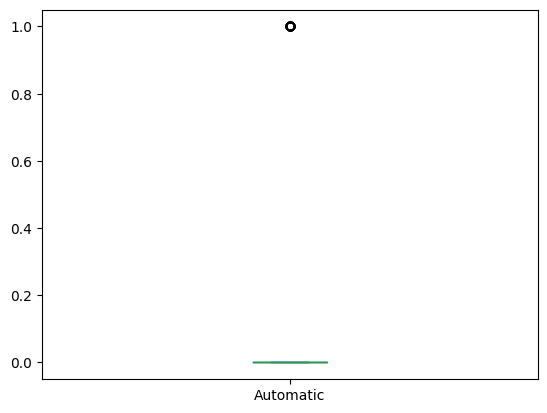

In [22]:
df['Automatic'].plot(kind = 'box')

In [23]:
Q1 = df['Automatic'].quantile(0.25)
Q3 = df['Automatic'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Automatic'] = df['Automatic'].clip(lower, upper)

<Axes: >

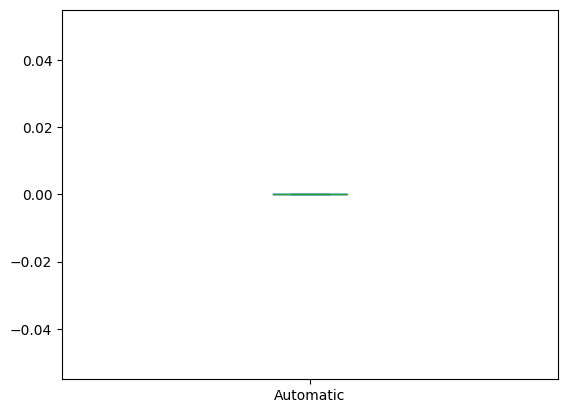

In [24]:
df['Automatic'].plot(kind = 'box')

<Axes: >

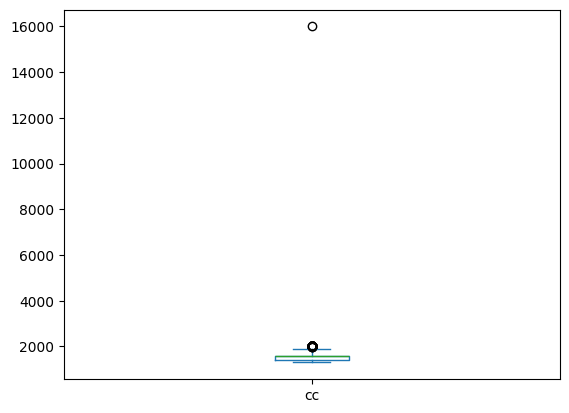

In [25]:
df['cc'].plot(kind = 'box')

In [26]:
Q1 = df['cc'].quantile(0.25)
Q3 = df['cc'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['cc'] = df['cc'].clip(lower, upper)

<Axes: >

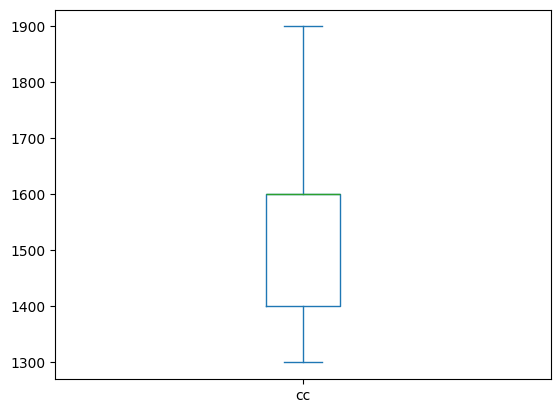

In [27]:
df['cc'].plot(kind = 'box')

<Axes: >

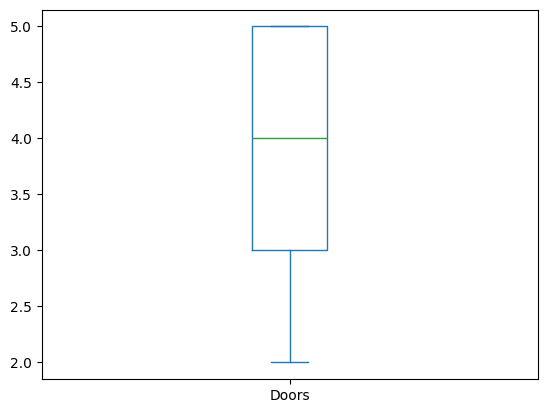

In [28]:
df['Doors'].plot(kind = 'box')

<Axes: >

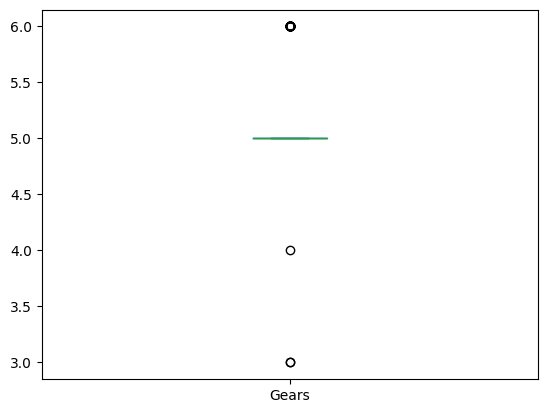

In [29]:
df['Gears'].plot(kind = 'box')

In [30]:
Q1 = df['Gears'].quantile(0.25)
Q3 = df['Gears'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Gears'] = df['Gears'].clip(lower, upper)

<Axes: >

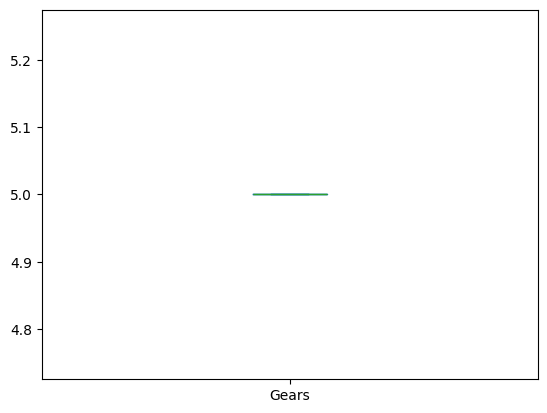

In [31]:
df['Gears'].plot(kind = 'box')

<Axes: >

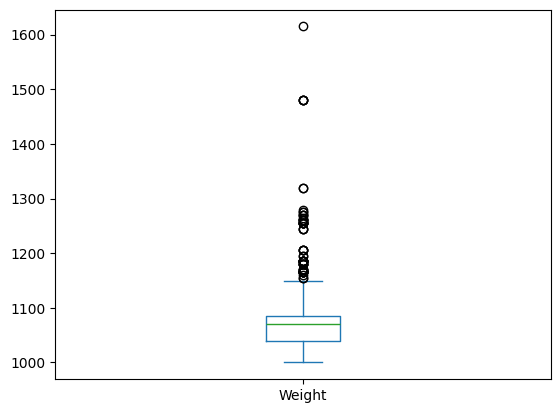

In [32]:
df['Weight'].plot(kind = 'box')

In [33]:
Q1 = df['Weight'].quantile(0.25)
Q3 = df['Weight'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Weight'] = df['Weight'].clip(lower, upper)

<Axes: >

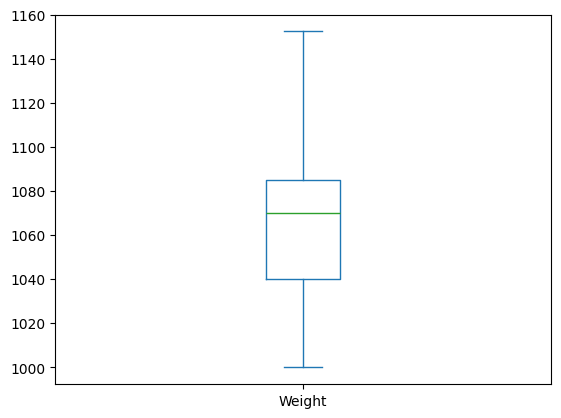

In [34]:
df['Weight'].plot(kind = 'box')

In [35]:
# to covert categorical data to binary vectors
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])

In [36]:
# to find cor-relation between variables
df.corr()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
Price,1.000000,-0.895340,-0.607949,0.024386,0.254427,NaN,0.129352,0.183010,NaN,NaN,0.507823
Age_08_04,-0.895340,1.000000,0.530670,0.076442,-0.129602,NaN,-0.136644,-0.146704,NaN,NaN,-0.476150
KM,-0.607949,0.530670,1.000000,-0.398364,-0.329729,NaN,0.258680,-0.036618,NaN,NaN,0.000977
Fuel_Type,0.024386,0.076442,-0.398364,1.000000,0.458771,NaN,-0.598360,-0.025339,NaN,NaN,-0.529262
HP,0.254427,-0.129602,-0.329729,0.458771,1.000000,NaN,0.098192,0.120139,NaN,NaN,0.024877
Automatic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cc,0.129352,-0.136644,0.258680,-0.598360,0.098192,NaN,1.000000,0.138433,NaN,NaN,0.717782
Doors,0.183010,-0.146704,-0.036618,-0.025339,0.120139,NaN,0.138433,1.000000,NaN,NaN,0.381177
Cylinders,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gears,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
# removing columns Automatic, Cylinders, Gears cause it not give usefull informaion for prediction
df.drop(['Automatic', 'Cylinders', 'Gears'], axis = 1, inplace = True)

<Axes: >

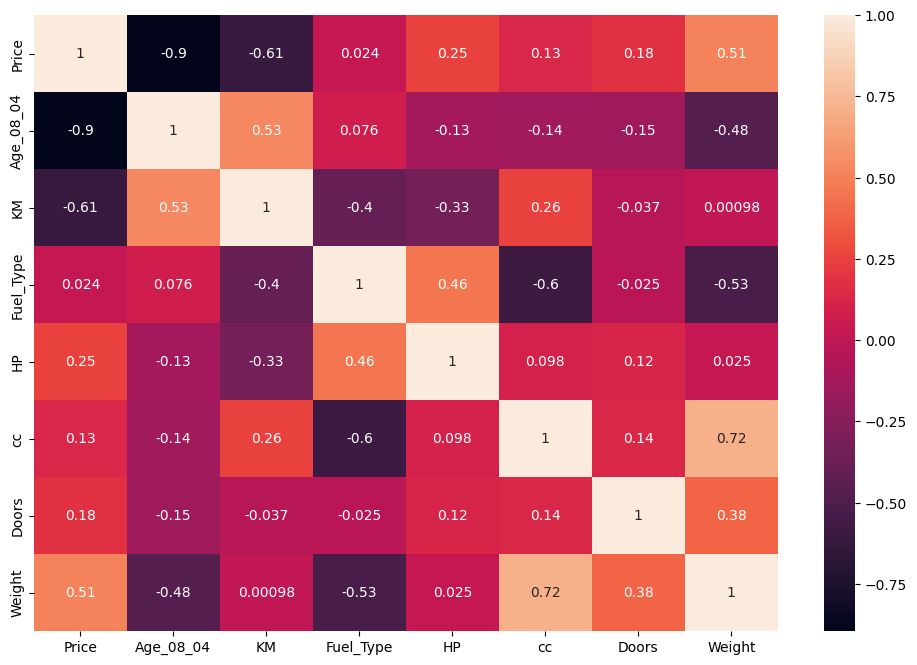

In [38]:
# correlation using visualization technique
plt.figure(figsize = (12, 8))
sns.heatmap(df.corr(), annot = True)

#### Detecting multicolinearity using Variace Inflation Factor

In [39]:
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

X = df[['Age_08_04', 'KM', 'HP', 'cc', 'Doors', 'Weight', 'Fuel_Type']]

In [40]:
Y=df["Age_08_04"]
X_age=X.drop('Age_08_04', axis = 1)

model = lr.fit(X_age, Y)
r2_Age = r2_score(Y, lr.predict(X_age))

VIF_Age = 1/(1-r2_Age)
VIF_Age

2.1311258089987164

In [41]:
Y=df["KM"]
X_KM=X.drop('KM', axis = 1)

model = lr.fit(X_KM, Y)
r2_KM = r2_score(Y, lr.predict(X_KM))

VIF_KM = 1/(1-r2_KM)
VIF_KM

2.0044558376218857

In [42]:
Y=df["HP"]
X_HP=X.drop('HP', axis = 1)

model = lr.fit(X_HP, Y)
r2_HP = r2_score(Y, lr.predict(X_HP))

VIF_HP = 1/(1-r2_HP)
VIF_HP

1.856277751413577

In [43]:
Y=df["cc"]
X_cc=X.drop('cc', axis = 1)

model = lr.fit(X_cc, Y)
r2_cc = r2_score(Y, lr.predict(X_cc))

VIF_cc = 1/(1-r2_cc)
VIF_cc

3.4137092362365387

In [44]:
Y=df["Doors"]
X_Doors=X.drop('Doors', axis = 1)

model = lr.fit(X_Doors, Y)
r2_Doors = r2_score(Y, lr.predict(X_Doors))

VIF_Doors = 1/(1-r2_Doors)
VIF_Doors

1.2966632486625618

In [45]:
Y=df["Weight"]
X_Weight = X.drop('Weight', axis = 1)

model = lr.fit(X_Weight, Y)
r2_Weight = r2_score(Y, lr.predict(X_Weight))

VIF_Weight = 1/(1-r2_Weight)
VIF_Weight

3.830833985747436

In [46]:
Y=df["Fuel_Type"]
X_Fuel_Type = X.drop('Fuel_Type', axis = 1)

model = lr.fit(X_Fuel_Type, Y)
r2_Fuel_Type = r2_score(Y, lr.predict(X_Fuel_Type))

VIF_Fuel_Type = 1/(1-r2_Fuel_Type)
VIF_Fuel_Type

2.9271656019982655

In [47]:
# no model having high multicolinearity so they are relevent to build the model

In [48]:
# spliting data set into training data and testing data
from sklearn.model_selection import train_test_split

X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) # 20 % data for testing, 80% for training
print(X_train.shape)
print(y_train.shape)

(1148, 7)
(1148,)


## Full Multiple Linear Regression

In [49]:
# Building model 

lr.fit(X_train, y_train) # training a model
y_pred = lr.predict(X_test) 

In [50]:
print(lr.coef_, lr.intercept_) # coefficient and intercept values
print(lr.score(X, y)) #accuracy score

[-1.05278810e+02 -1.49486688e-02  4.60679360e+02  2.34901950e+01
 -2.19165085e+00 -1.31400560e+02  2.57822567e+01] -9453.943195086254
0.865237868528224


In [51]:
# Model Evaluation using mean squared error, mean absolute error, root mean squared error and r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

# R2 Score
r2_score = r2_score(y_test, y_pred)

# Print results
print("Model  Evaluation")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2_score)

Model  Evaluation
MAE : 874.9051254504102
MSE : 1278904.3704666847
RMSE : 1130.8865418187117
R2 Score : 0.850039183654592


## Building model by Remove less important/high VIF variables.

In [52]:
X = df.drop(['Weight'], axis=1) # droping weight cause it's vif is nearly 4 moderate but still it will slightly effect performance
y = df['Price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
lr2 = LinearRegression()

lr2.fit(X_train, y_train)

# Prediction
y_pred = lr2.predict(X_test)

In [53]:
del r2_score # used del r2_score cause it is getting stored in memory and causing error in evaluation of second model

In [54]:
# Model Evaluation using mean squared error, mean absolute error, root mean squared error and r2_score

from sklearn.metrics import r2_score
# MAE
mae2 = mean_absolute_error(y_test, y_pred)

# MSE
mse2 = mean_squared_error(y_test, y_pred)

# RMSE
rmse2 = np.sqrt(mse2)

# R2 Score
r2_2 = r2_score(y_test, y_pred)

# Print Results
print("Model 2 Evaluation")

print("MAE :", mae2)
print("MSE :", mse2)
print("RMSE :", rmse2)
print("R2 Score :", r2_2)

Model 2 Evaluation
MAE : 2.205603876076509e-12
MSE : 8.329449373791812e-24
RMSE : 2.8860785460191155e-12
R2 Score : 1.0


## Ridge and Lasso

In [55]:
# importing libraires for accuarcy score and ridge and lasso
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score

In [56]:
# Ridge is one of the regularization technique used to reduce overfitting and multicolinearity
ridge = Ridge(alpha = 1.0)

model_rd = ridge.fit(X_train, y_train)
y_pred_rd = ridge.predict(X_test)

ridge_mae = mean_absolute_error(y_test, y_pred_rd)
ridge_mse = mean_squared_error(y_test, y_pred_rd)
ridge_rmse = np.sqrt(mse)
r2= r2_score(y_pred_rd, y_test)

print('Ridge Regression')
print('MAE', ridge_mae)
print('MSE', ridge_mse)
print('RMSE', ridge_rmse)
print('R2 Score', r2)

Ridge Regression
MAE 5.606498773281142e-07
MSE 5.29712079818637e-13
RMSE 1130.8865418187117
R2 Score 1.0


In [57]:
# Lasso is also one of thee regularization technique used to reduce overfitting and important feature selection and reduce coeficient to 0
lasso = Lasso(alpha=1.0)

# Train
model_lasso = lasso.fit(X_train, y_train)

# Prediction
y_pred_lasso= lasso.predict(X_test)

# Metrics
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

lasso_mse = mean_squared_error(y_test, y_pred_lasso)

lasso_rmse = np.sqrt(lasso_mse)

lasso_r2 = r2_score(y_test, y_pred_lasso)

# Print
print("Lasso Regression")
print("MAE :", lasso_mae)
print("MSE :", lasso_mse)
print("RMSE :", lasso_rmse)
print("R2 Score :", lasso_r2)

Lasso Regression
MAE : 0.00028710378927499836
MSE : 1.287745230206626e-07
RMSE : 0.00035885167272936406
R2 Score : 0.9999999999999849


# Building Model by selecting only few important features

In [58]:
X = df[['Age_08_04', 'KM', 'HP']] # selected most important features
y = df['Price'] # target variables

# Spliting dataset into train test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# training the model

lr3 = LinearRegression()

lr3.fit(X_train, y_train)

# Prediction

y_pred = lr3.predict(X_test)

In [59]:
# Model Evaluation using mean squared error, mean absolute error, root mean squared error and r2_score

mae3 = mean_absolute_error(y_test, y_pred)

mse3 = mean_squared_error(y_test, y_pred)

rmse3 = np.sqrt(mse3)

r2_3 = r2_score(y_test, y_pred)

# Print
print("Model 3 Evaluation")
print("MAE :", mae3)
print("MSE :", mse3)
print("RMSE :", rmse3)
print("R2 Score :", r2_3)

Model 3 Evaluation
MAE : 936.127030802886
MSE : 1466130.3609446378
RMSE : 1210.8387014564069
R2 Score : 0.8280855778795909
